<a href="https://colab.research.google.com/github/mareylugo/ICD-2026/blob/Practicas/Practica_1_Cervical_cancer_risk_factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Introducción a la Ciencia de Datos 2026**
Posgrado en Ciencias de la Computación - CICESE  
Practica 1 - Análisis Exploratorio y Visualización  
Luz Marey Lugo Acedo

## Introducción
El cáncer cervical o de cuello uterino es el quinto cancer más común en mujeres alrededor del mundo según la OMS[1], el riesgo de desarrollar este cáncer es reducible y si es detectado a tiempo puede tratarse y curarse en su totalidad. La mayor causa son las lesiones causadas por el virus del papiloma humano. Las tasas de mortalidad más altas son entre las mujeres de clase a media y baja debido a la falta de acceso a la salud y a la detección tardía. En 2024 hubieron 280 000 muertes.   

 El presente Dataset es el resultado de un censado de factores de riesgo para cáncer cervical en el Hospital Universitario de Caracas, en donde se cubre historial médico de las pacientes, información demográfica y hábitos, por ejemplo, si fuman o si han tenido alguna enfermedad de transmisión sexual, así como los resultados de sus estudios médicos para detectar dicho diagnóstico. Hay información faltante ya que hay preguntas que las pacientes decidieron no responder, estos datos se registraron con un signo de interrogación (?). Contiene 858 registros y 36 atributos. [2]  
 Las cuatro variables objetivo son las de los siguientes estudios que se realizan para evaluar lesiones cancerosas o pre-cancerosas: Cytología, Hinselmann, Schiller y Biopsia. En el registro se marcan como 0 las que los médicos evaluaron como negativas, mientras que las positivas (o anormales) se marcaron con 1. [3]


## Verificación inicial del data set
Para esta sección se evaluará si las siguientes condiciones se cumplen:

*   Al menos 500 registros y 10 atributos.

*   Al menos 2 atributos numéricos y 2 atributos categóricos.

*   Al menos un atributo que pueda funcionar como variable objetivo.
*   Datos reales, presentando al menos una de las siguientes condiciones: valores faltantes, registros duplicados, inconsistencias de codificación, o valores fuera de rango.

In [170]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#cargar el dataset en en un dataframe de pandas llamado df
df = pd.read_csv('https://raw.githubusercontent.com/mareylugo/ICD-2026/Practicas/risk_factors_cervical_cancer.csv')

In [171]:
# Uso de funciones relacionadas a las dimensiones del dataframe.
print(f"Dimensiones del DataFrame: {df.shape[0]} Instances, {df.shape[1]} Features")

# Imprimir la información del dataframe
print("\nInformación del DataFrame:")
df.info()

Dimensiones del DataFrame: 858 Instances, 36 Features

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 

In [172]:
# Revisar si cumple con el requisito "Al menos 500 registros y 10 atributos."
print(f"Number of instances: {df.shape[0]}")
print(f"Number of attributes: {df.shape[1]}")
if df.shape[0] > 500:
    print("There are more than 500 instances, we can continue with the analysis.")
else:
    print("We can't continue because the dataset has less than 500 instances.")
if df.shape[1] > 10:
    print("There are more than 10 attributes, we can continue with the analysis.")
else:
    print("We can't continue because the dataset has less than 10 attributes.")

Number of instances: 858
Number of attributes: 36
There are more than 500 instances, we can continue with the analysis.
There are more than 10 attributes, we can continue with the analysis.


Según los datos devueltos, se cumple la primera condición de dimensiones: mayor a 500 entradas (858) y mayor a 10 atributos (36).

Para el segundo requisito, el cual es al menos 2 atributos numéricos y al menos 2 atributos catégoricos, observamos que los datos recogidos en los atributos categóricos fueron registrados con 0 y 1, siendo el negativo o "no" 0 y el positivo como 1, los cuales podrían ser trabajados como Int o booleanos. Los registros numéricos (como los años que se ha fumado) que se podrían trabajar como float, están en números continuos, así como también  en su caso discretos (como la edad). Con estas distinciones haremos la categorización de ambos tipos de atributos.

In [173]:
#Sección para revisar cantidad de atributos categóricos y ubicar cuáles son.
categorical_attributes = []

for col in df.columns:
    # Reemplazo de ? por NaN para evaluar solo los 0 y 1
    temp_series = df[col].replace('?', np.nan)

    # Hratar de cambiar otros formatos a numerico.
    try:
        numeric_series = pd.to_numeric(temp_series)
        unique_vals = numeric_series.dropna().unique()

        # Revisar si los valores en cada atributo se encuentran conformados por ceros y unos
        if set(unique_vals).issubset({0.0, 1.0}):
            categorical_attributes.append(col)
    except ValueError:
        # Si no es una columna numérica, se la salta
        continue

print("Categorical Attributes (0 and 1 only):")
for attr in categorical_attributes:
    print(f"- {attr}")
print(f"Quantity of categorical attributes {len(categorical_attributes)}")
if len(categorical_attributes) > 2:
    print("There are more than 2 categorical attributes, we can continue")
else:
    print("We can't continue because the dataset has less than 2 categorical attributes.")


Categorical Attributes (0 and 1 only):
- Smokes
- Hormonal Contraceptives
- IUD
- STDs
- STDs:condylomatosis
- STDs:cervical condylomatosis
- STDs:vaginal condylomatosis
- STDs:vulvo-perineal condylomatosis
- STDs:syphilis
- STDs:pelvic inflammatory disease
- STDs:genital herpes
- STDs:molluscum contagiosum
- STDs:AIDS
- STDs:HIV
- STDs:Hepatitis B
- STDs:HPV
- Dx:Cancer
- Dx:CIN
- Dx:HPV
- Dx
- Hinselmann
- Schiller
- Citology
- Biopsy
Quantity of categorical attributes 24
There are more than 2 categorical attributes, we can continue


In [174]:
continuous_attributes = []

for col in df.columns:
    # Reemplazo de ? con NaN
    temp_series = df[col].replace('?', np.nan)

    # tratar de transformar en valores numéricos, si no son valores numéricos no nos sirve
    try:
        numeric_series = pd.to_numeric(temp_series)

        # revisar si una columna tiene mas de dos variables ignorando el NaN, o si se encuentra como float
        unique_vals_non_nan = numeric_series.dropna().unique()

        # Exclusión de las categorías que se guardaron como categóricas
        if col not in categorical_attributes:
            #Si el contenido es númerico y tiene más de dos variables o se encuentra
            #guardado como float, lo más probable es que este conformado este atributo como número continuo.
            # Se usan > 2 valores únicos para distinguir de valores Integer que no sean 0 y 1 y
            # sean discretos aunque no sean continuos en el sentido de que tengan decimales, o en su caso sean float

            if len(unique_vals_non_nan) > 2 or pd.api.types.is_float_dtype(numeric_series.dtype):
                continuous_attributes.append(col)

    except ValueError:
        # Si no es una columna numérica, se la salta
        continue

print("Continuous Attributes:")
for attr in continuous_attributes:
    print(f"- {attr}")

print(f"Quantity of continuous attributes: {len(continuous_attributes)}")
if len(continuous_attributes) > 2:
    print("There are more than 2 continuous attributes, we can continue.")
else:
    print("We don't have enough continuous attributes to continue.")

Continuous Attributes:
- Age
- Number of sexual partners
- First sexual intercourse
- Num of pregnancies
- Smokes (years)
- Smokes (packs/year)
- Hormonal Contraceptives (years)
- IUD (years)
- STDs (number)
- STDs: Number of diagnosis
- STDs: Time since first diagnosis
- STDs: Time since last diagnosis
Quantity of continuous attributes: 12
There are more than 2 continuous attributes, we can continue.


Según los datos devueltos, se cumplen los requisitos de más de dos atributos categóricos (24) de forma Integer y más de dos atributos númericos (12) en forma de float, a excepción de los atributos con números enteros con mayor variedad de 0 y 1 en sus registros.

Las variables objetivo son los resultados registrados de los 4 estudios para detectar lesiones pre-cancérigenas o cancerígenas, estos se encuentran entre los atributos categóricos, las cuales son:

*  Hinselmann
*  Schiller
*  Citology
*  Biopsy

En los registros hay información faltante que por respeto a la privacidad de las pacientes no fue incluída. En el espacio siguiente se imprime la cantidad de espacios sin responder (?) que hay por cada uno de los atributos (columnas)


In [175]:
print("Quantity of '?' in each attribute:")
for col in df.columns:
    question_mark_count = df[col].astype(str).str.count('\?').sum()
    if question_mark_count > 0:
        print(f"- {col}: {int(question_mark_count)}")
    else:
        print(f"- {col}: No '?' values")

Quantity of '?' in each attribute:
- Age: No '?' values
- Number of sexual partners: 26
- First sexual intercourse: 7
- Num of pregnancies: 56
- Smokes: 13
- Smokes (years): 13
- Smokes (packs/year): 13
- Hormonal Contraceptives: 108
- Hormonal Contraceptives (years): 108
- IUD: 117
- IUD (years): 117
- STDs: 105
- STDs (number): 105
- STDs:condylomatosis: 105
- STDs:cervical condylomatosis: 105
- STDs:vaginal condylomatosis: 105
- STDs:vulvo-perineal condylomatosis: 105
- STDs:syphilis: 105
- STDs:pelvic inflammatory disease: 105
- STDs:genital herpes: 105
- STDs:molluscum contagiosum: 105
- STDs:AIDS: 105
- STDs:HIV: 105
- STDs:Hepatitis B: 105
- STDs:HPV: 105
- STDs: Number of diagnosis: No '?' values
- STDs: Time since first diagnosis: 787
- STDs: Time since last diagnosis: 787
- Dx:Cancer: No '?' values
- Dx:CIN: No '?' values
- Dx:HPV: No '?' values
- Dx: No '?' values
- Hinselmann: No '?' values
- Schiller: No '?' values
- Citology: No '?' values
- Biopsy: No '?' values


<>:3: SyntaxWarning: invalid escape sequence '\?'
<>:3: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipykernel_1590/1118037395.py:3: SyntaxWarning: invalid escape sequence '\?'
  question_mark_count = df[col].astype(str).str.count('\?').sum()


# Calidad de los datos
Para el análisis de la calidad de estos datos se revisarán las siguientes condiciones:


* Patrón de valores faltantes
* Duplicados
* Valores imposibles
* Cardinalidad de los atributos categóricos.



/tmp/ipykernel_1590/1763911963.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attributes_with_missing_data.index, y=attributes_with_missing_data.values, palette='viridis')


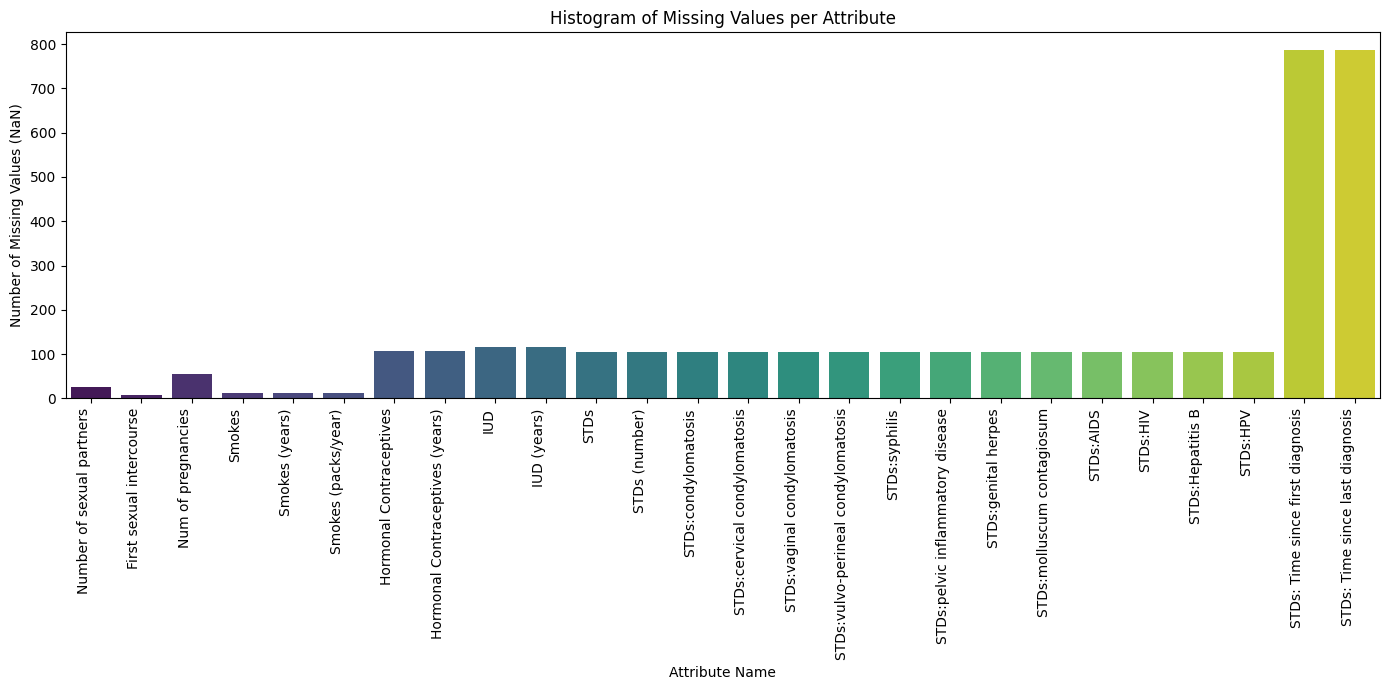

In [176]:
# Histograma con datos faltantes por atributo
# Filtrar los atributos que no les faltan registros
missing_series = df.isin(['?']).sum()
attributes_with_missing_data = missing_series[missing_series > 0]

if not attributes_with_missing_data.empty:
    plt.figure(figsize=(14, 7))
    sns.barplot(x=attributes_with_missing_data.index, y=attributes_with_missing_data.values, palette='viridis')
    plt.xticks(rotation=90, ha='right')
    plt.xlabel('Attribute Name')
    plt.ylabel('Number of Missing Values (NaN)')
    plt.title('Histogram of Missing Values per Attribute')
    plt.tight_layout() # Ajustar layout
    plt.show()
else:
    print("No attributes with missing values found after replacement.")

Figura 1. Histograma con la cantidad de datos faltantes por atributo.

Para los atributos con mayor cantidad de faltantes se puede visualizar en el histograma en la figura [1] que los datos con menos registros son los relacionados con el tiempo de diagnóstico de enfermedades de transmisión sexual (STDs: Time since first diagnosis y STDs: Time since last diagnosis). Debido a que según el listado faltan de estos dos campos 787 veces, lo mejor sería no usar estos dos atributos al momento de analizar los datos, ya que resultaría en una pérdida del 91.72% si se quitaran los registros a los que les faltan esos datos, dejando el resto del muestreo muy pobre. Para el resto, depende de su relación con las variables objetivo: si faltan atributos para los pocos valores positivos en las variables objetivo, puede ser un dataset de muy baja calidad ya que no podríamos estudiar la relación de los factores de riesgo con diagnósticos positivos de lesiones cancerosas con fiabilidad.

In [177]:
#Imprimir variables objetivo positivos
target_variables = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

print("Quantity of positive data (value '1') for target variables:")
for col in target_variables:
    # Ensure the column is numeric and then count '1's
    # pd.to_numeric with errors='coerce' handles any non-numeric values by turning them into NaN
    # Then, .eq(1) checks for equality with 1, and .sum() counts True values (which are treated as 1)
    positive_count = pd.to_numeric(df[col], errors='coerce').eq(1).sum()
    print(f"- {col}: {int(positive_count)}")

Quantity of positive data (value '1') for target variables:
- Hinselmann: 35
- Schiller: 74
- Citology: 44
- Biopsy: 55


La cantidad de datos positivos vs la cantidad de datos negativos es bastante desequilibrada para las cuatro variables objetivo, además de ser pocos.

Debido a que no hay algún identificador para cada registro, es difícil suponer que hay valores duplicados, ya que dos personas distintas podrían compartir atributos.

Para revisar si hay valores imposibles, podemos observar que a excepción del atributo de cantidad de embarazos y el de número de parejas sexuales, el resto de atributos numéricos están en años.

Según los registros de récord Guiness [4], la madre mas prolífica tuvo 69 hijos en 27 embarazos, así que se usará esa cantidad de embarazos como el tope para encontrar valores anormales.

El récord guiness para la persona más longeva [5] se lo lleva una mujer que alcanzó los 122 años con 164 días, así que los valores en la tabla tendrían como tope esta cantidad para revisar si hay edades atípicas (erróneas) registardas.
Para los atributos numéricos en años, deberían ser valores menores a la edad (Age) del registro.

Para el registro de parejas sexuales por persona, las cantidades pueden variar enormemente dependiendo de la historia personal de la paciente, así que solo se revisaría cuál fue el mayor número registrado.

In [178]:
pregnancies = pd.to_numeric(df['Num of pregnancies'], errors='coerce')
# Filter for instances where 'Num of pregnancies' is greater than 27
anamolous_pregnancies = pregnancies[pregnancies > 27]

if not anamolous_pregnancies.empty:
    print(f"Number of instances with 'Num of pregnancies' > 27: {len(anamolous_pregnancies)}")
else:
    print("All values for num of pregnancies are acceptable")

All values for num of pregnancies are acceptable


In [179]:
age = pd.to_numeric(df['Age'], errors='coerce')
# Filter for instances where 'Age' is greater than 122
anamolous_age = age[age > 122]

if not anamolous_age.empty:
    print(f"Number of instances with 'Age' > 122: {len(anamolous_age)}")
else:
    print("All values for age are acceptable")

All values for age are acceptable


In [180]:
anomalous_instances_count_new = 0

# Ensure 'Age' column is numeric for comparison
df['Age_numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# Iterate through continuous attributes, excluding 'Age', 'Number of sexual partners', and 'Num of pregnancies'
excluded_cols = ['Age', 'Number of sexual partners', 'Num of pregnancies', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis']

for col in continuous_attributes:
    if col in excluded_cols:
        continue # Skip excluded columns and diagnosis counts as they are not expected to be less than age

    # Convert the current column to numeric, handling '?' as NaN
    numeric_col = pd.to_numeric(df[col], errors='coerce')

    # Find instances where the current numeric attribute is greater than 'Age'
    anamolous_values = df[(numeric_col > df['Age_numeric']) & numeric_col.notna() & df['Age_numeric'].notna()]

    if not anamolous_values.empty:
        print(f"Instances where '{col}' is greater than 'Age':")
        display(anamolous_values[['Age', col]])
        anomalous_instances_count_new += len(anamolous_values)

if anomalous_instances_count_new == 0:
    print("All numeric values (excluding 'Number of sexual partners' and 'Num of pregnancies') are acceptable compared to age.")
else:
    print(f"Total number of instances with numerical values greater than age (excluding 'Number of sexual partners' and 'Num of pregnancies'): {anomalous_instances_count_new}")

# Drop the temporary 'Age_numeric' column
df.drop(columns=['Age_numeric'], inplace=True)

Instances where 'First sexual intercourse' is greater than 'Age':


,Age,First sexual intercourse
312,23,27.0
812,14,16.0


Total number of instances with numerical values greater than age (excluding 'Number of sexual partners' and 'Num of pregnancies'): 2


In [181]:
num_sexual_partners = pd.to_numeric(df['Number of sexual partners'], errors='coerce')
biggest_num_partners = num_sexual_partners.max()

print(f"The biggest number of sexual partners recorded is: {biggest_num_partners}")

The biggest number of sexual partners recorded is: 28.0


In [182]:
anomalous_negative_count = 0

# Combine all potentially numerical columns from continuous and categorical lists
all_numerical_cols = list(set(continuous_attributes + categorical_attributes))

print("Checking for numerical values below 0:")
for col in all_numerical_cols:
    # Convert column to numeric, handling '?' as NaN
    numeric_col = pd.to_numeric(df[col], errors='coerce')

    # Filter for values less than 0 and not NaN
    negative_values_instances = df[(numeric_col < 0) & numeric_col.notna()]

    if not negative_values_instances.empty:
        print(f"Instances where '{col}' has values less than 0:")
        display(negative_values_instances[['Age', col]])
        anomalous_negative_count += len(negative_values_instances)

if anomalous_negative_count == 0:
    print("All numerical values are acceptable (no values below 0).")
else:
    print(f"Total number of instances with numerical values below 0: {anomalous_negative_count}")

Checking for numerical values below 0:
All numerical values are acceptable (no values below 0).


Según las condiciones que se han establecido, los valores para edad y de número de embarazos son aceptables para su análisis, para el resto de los datos parecen estar también dentro de rangos aceptables a excepción de la edad de primera relación sexual en donde superaba la edad registrada, es decir no tiene sentido tener valores mayores a la edad de vida, así que esos dos instances para el caso de estudio de ese atributo serían removidos. También se revisó si había valores negativos (que por ser valores en años no podrían ser válidos) de los cuales no se encontró ninguno.

Respecto a la cardinalidad de los valores categóricos, todos son 0 y 1, así que solo cuentan con 2 categorías, es decir una cardinalidad baja.

# Análisis Univariado

Para el análisis univarado, se hará una visualización de como se conforman los atributos continuos y los atributos categóricos. Para efectos de mejor visualización se ignorarán los datos faltantes los atributos STDs: Time since first diagnosis y STDs: Time since last diagnosis

Generando visualizaciones univariadas para atributos continuos (Histogramas):


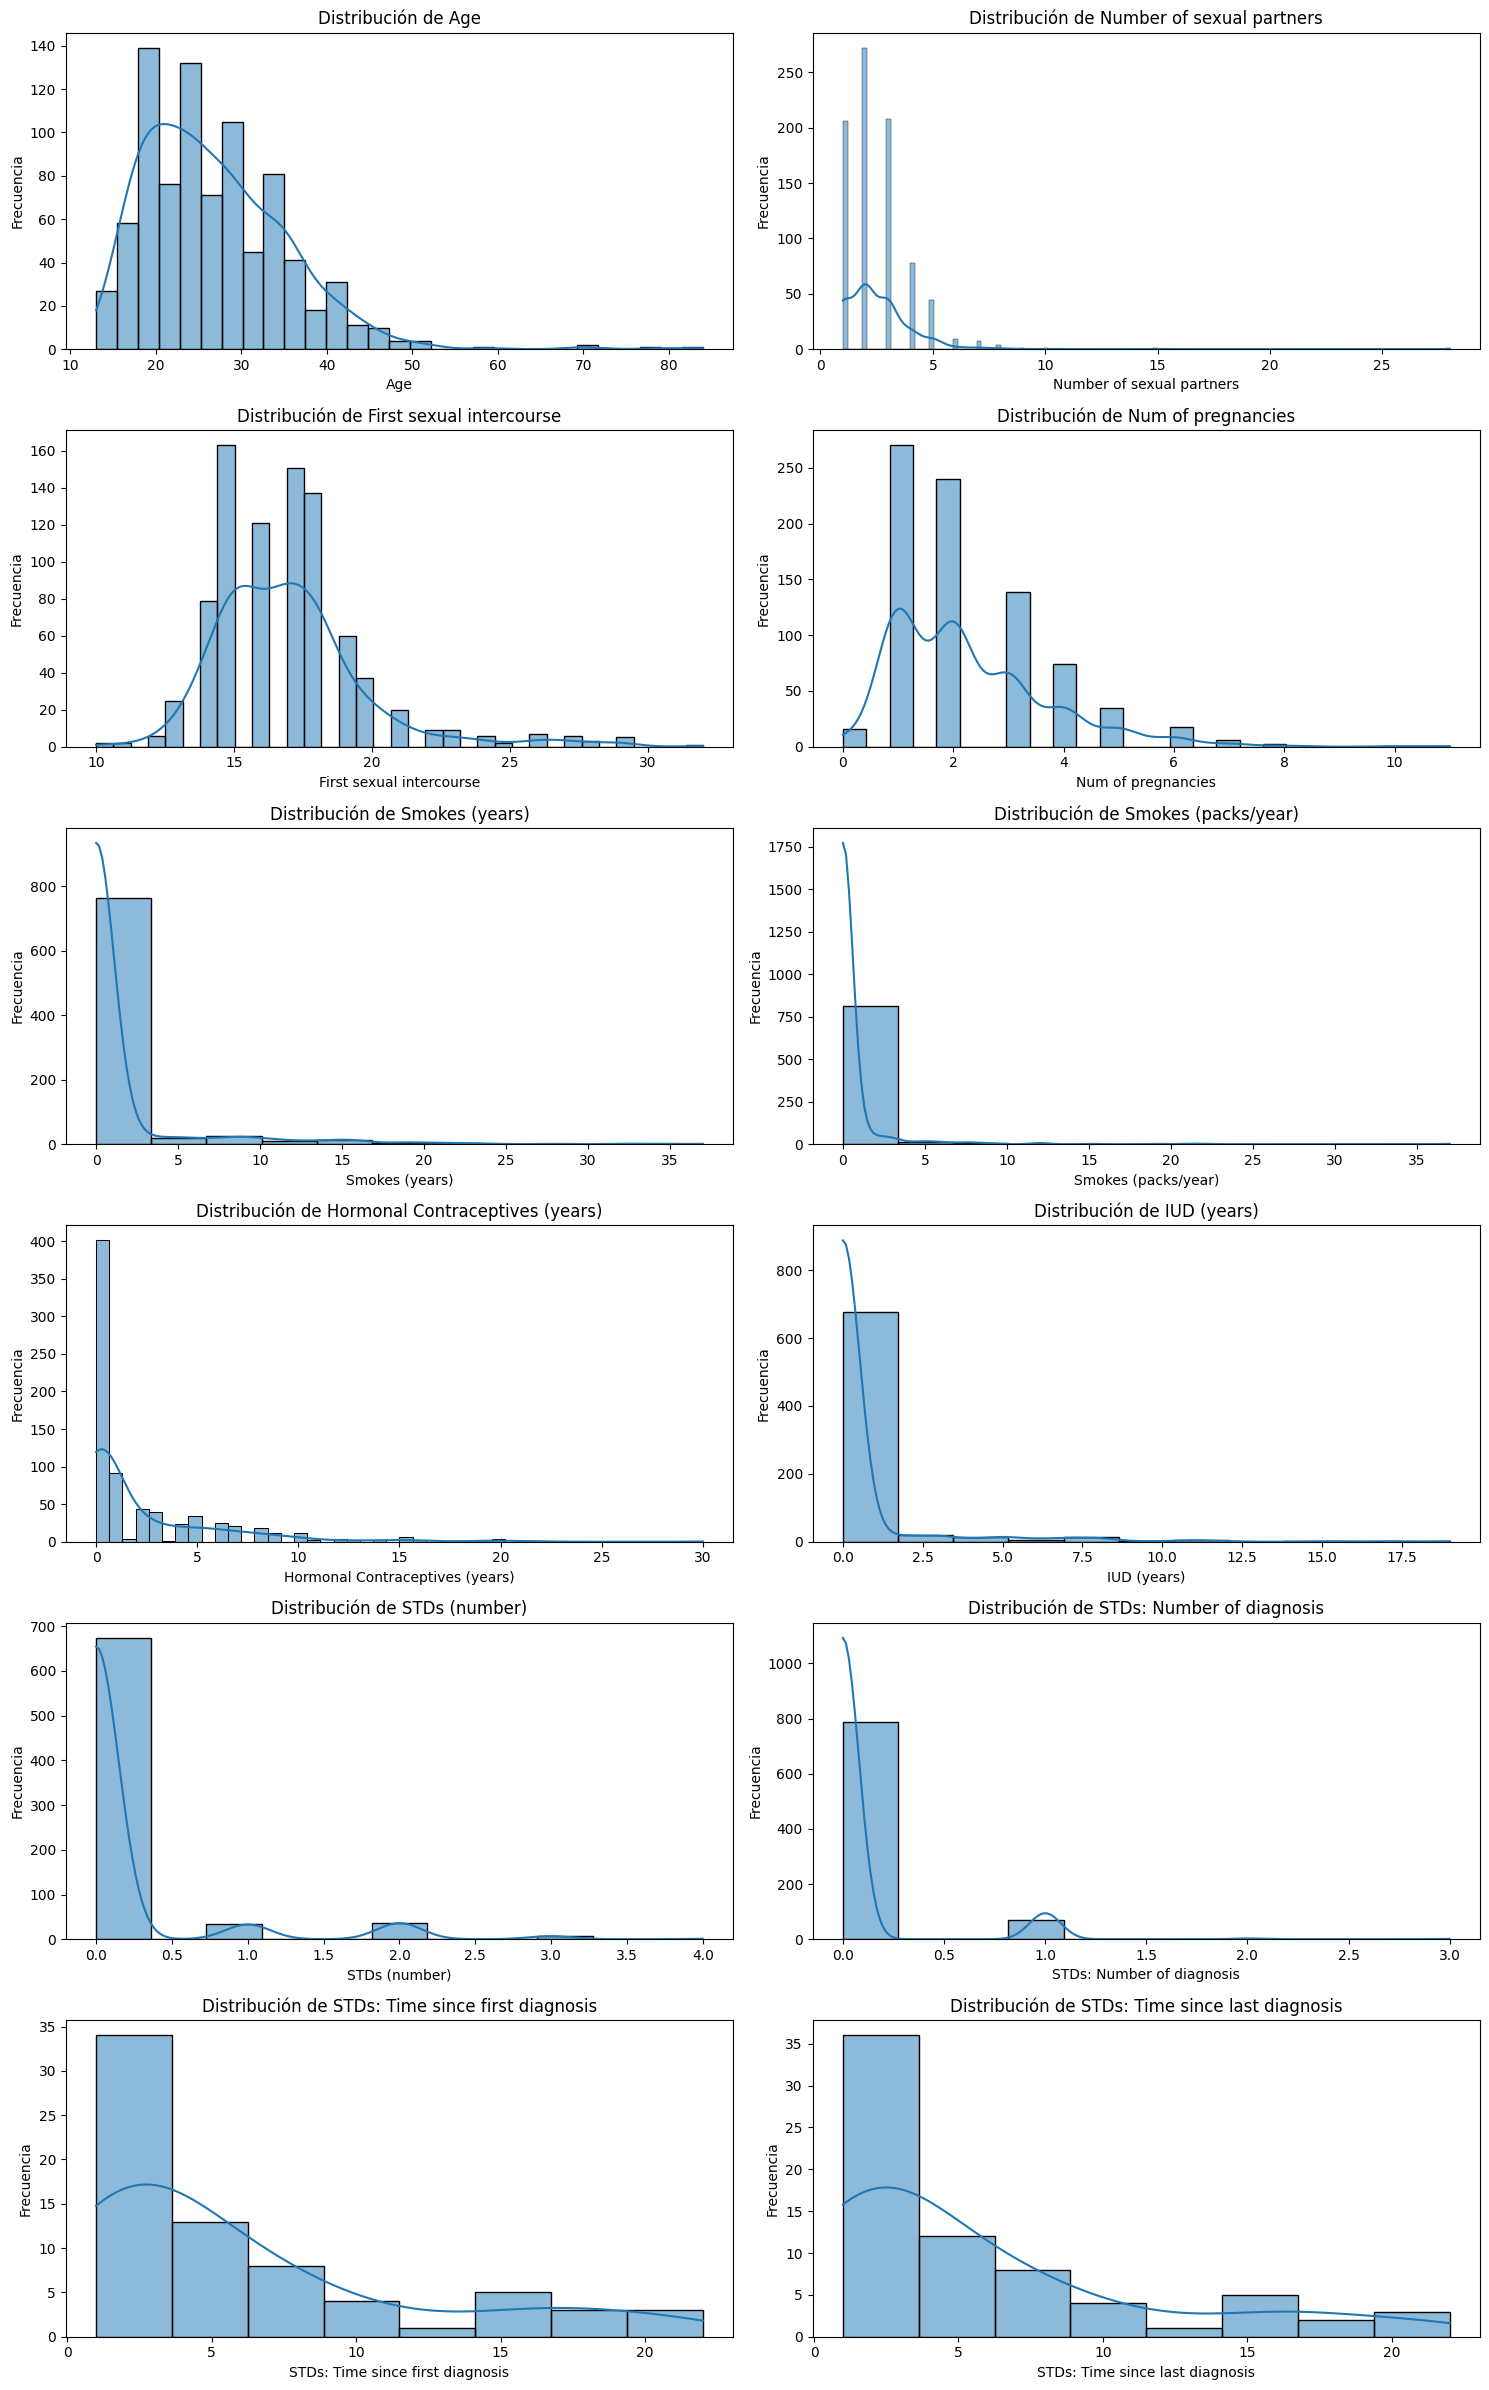

In [183]:
# Excluimos las columnas 'STDs: Time since first diagnosis' y 'STDs: Time since last diagnosis'
# en 'filtered_continuous_attribyres vamos a guardar los 12 atributos continuos'
print("Generando visualizaciones univariadas para atributos continuos (Histogramas):")
filtered_continuous_attributes = continuous_attributes# Determinar el número de filas para el subplot basado en la cantidad de atributos
num_attributes = len(continuous_attributes)
num_cols = 2 # Puedes ajustar el número de columnas si quieres una distribución diferente
num_rows = (num_attributes + num_cols - 1) // num_cols # Calcular el número de filas necesario

plt.figure(figsize=(15, num_rows * 4)) # Ajustar el tamaño de la figura dinámicamente

for i, col in enumerate(filtered_continuous_attributes):
    plt.subplot(num_rows, num_cols, i + 1)
    # Convertir la columna a numérica, forzando los errores a NaN, y luego eliminando NaNs para el trazado
    sns.histplot(pd.to_numeric(df[col], errors='coerce').dropna(), kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


En la figura 2. Se hicieron gráficas univariables de distribución de datos por cada atributo continuo.

Generando visualizaciones univariadas para atributos categóricos (Count Plots):


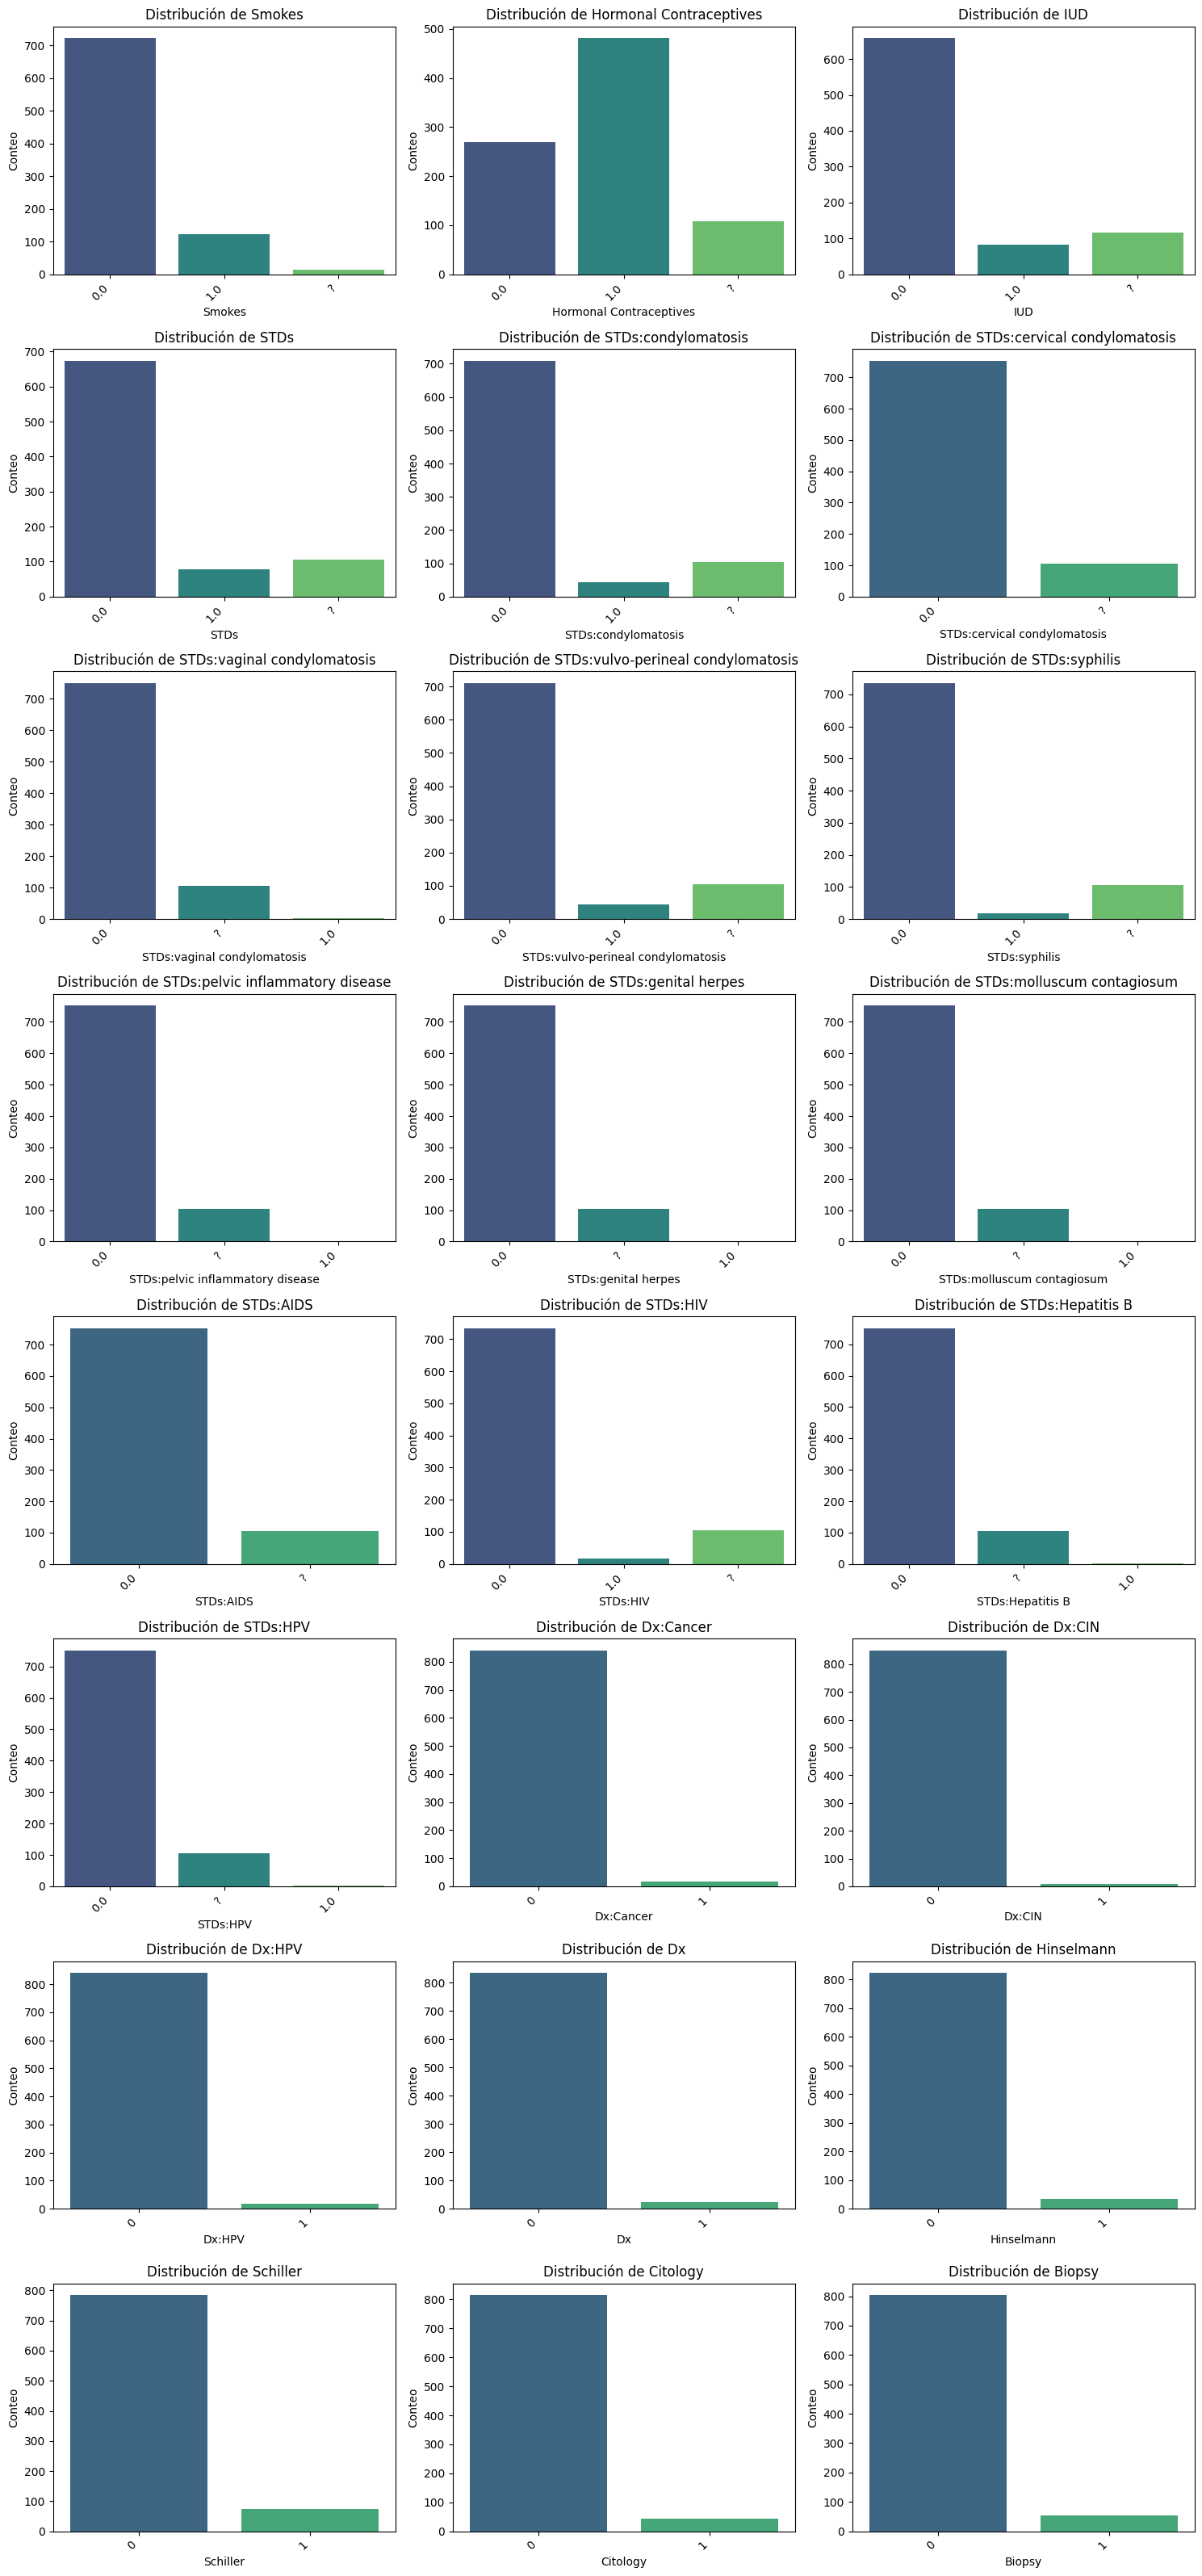

In [184]:
print("Generando visualizaciones univariadas para atributos categóricos (Count Plots):")

num_attributes_cat = len(categorical_attributes)
num_cols_cat = 3  # Número de columnas para los subplots de categóricos
num_rows_cat = (num_attributes_cat + num_cols_cat - 1) // num_cols_cat

plt.figure(figsize=(num_cols_cat * 5, num_rows_cat * 4))

for i, col in enumerate(categorical_attributes):
    plt.subplot(num_rows_cat, num_cols_cat, i + 1)
    # Asegurarse de que los valores sean de tipo objeto o cadena para evitar problemas con sns.countplot
    sns.countplot(x=df[col].astype(str), hue=df[col].astype(str), palette='viridis', legend=False)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


Figura 3. Gráficas univariables de los atributos categóricos.

In [185]:
target_variables = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
results = []

for col in target_variables:
    # Convertir la columna a numérica (manejar posibles NaNs después de replace('?', np.nan))
    numeric_col = pd.to_numeric(df[col], errors='coerce')

    # Eliminar NaNs para el conteo si existen
    clean_col = numeric_col.dropna()

    positive_count = clean_col.eq(1).sum()
    negative_count = clean_col.eq(0).sum()
    total_count = positive_count + negative_count

    if total_count > 0:
        positive_percentage = (positive_count / total_count) * 100
    else:
        positive_percentage = 0.0

    results.append({
        'Variable Objetivo': col,
        'Positivos': int(positive_count),
        'Negativos': int(negative_count),
        'Porcentaje de Positivos': f'{positive_percentage:.2f}%'
    })

# Crear un DataFrame a partir de los resultados y mostrarlo
display(pd.DataFrame(results))


,Variable Objetivo,Positivos,Negativos,Porcentaje de Positivos
0,Hinselmann,35,823,4.08%
1,Schiller,74,784,8.62%
2,Citology,44,814,5.13%
3,Biopsy,55,803,6.41%


La cantidad de valores positivos para estudio de valores de riesgo se encuentran impresos en esta tabla, con valores escasos para el estudio o entrenamiento de patrones. Estos son los valores que nos interesan.

Generando gráficos de barras para las variables objetivo:


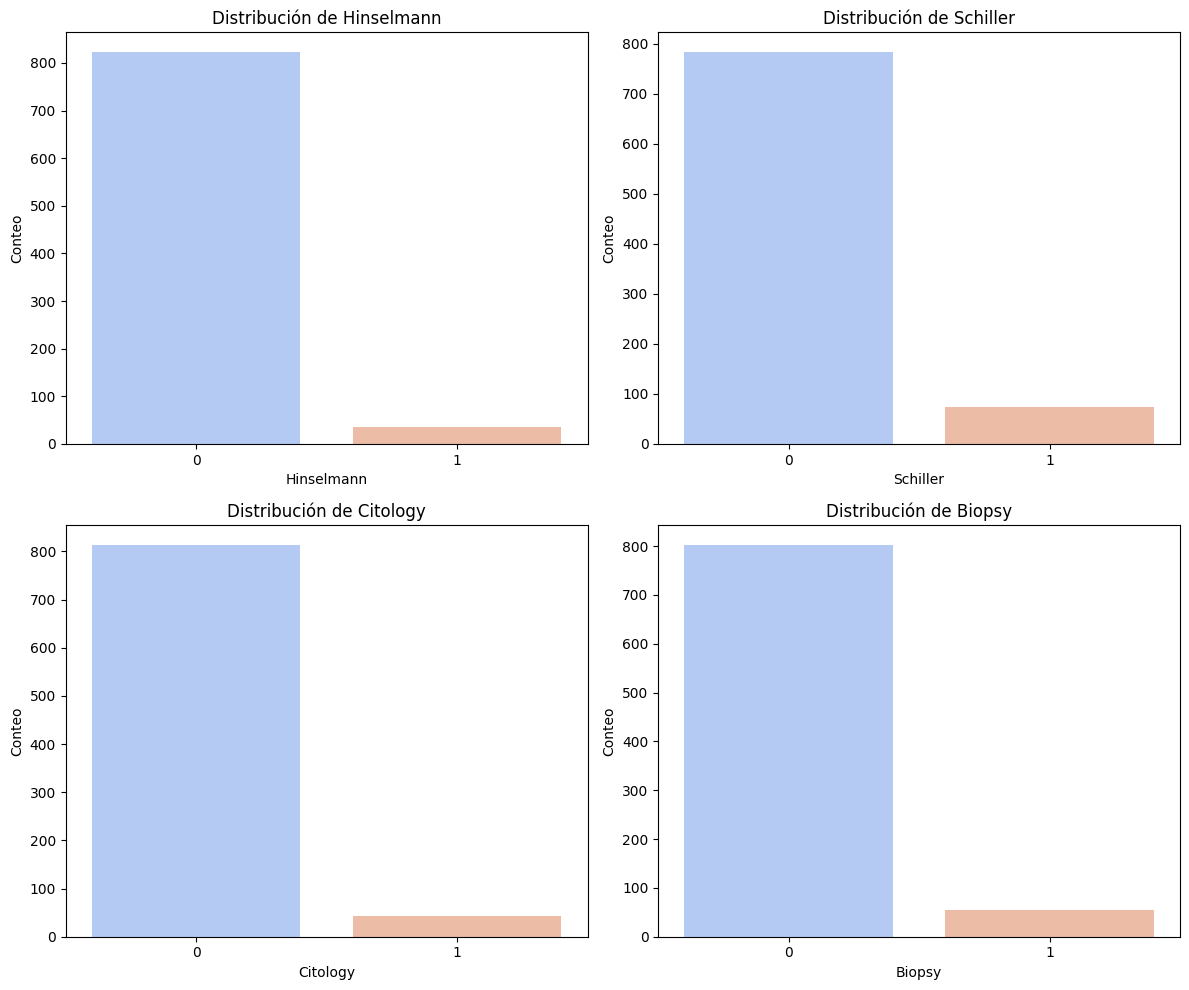

In [186]:
target_variables = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

print("Generando gráficos de barras para las variables objetivo:")

# Determinar el número de filas para el subplot
num_target_vars = len(target_variables)
num_cols_target = 2 # Puedes ajustar el número de columnas
num_rows_target = (num_target_vars + num_cols_target - 1) // num_cols_target

plt.figure(figsize=(num_cols_target * 6, num_rows_target * 5))

for i, col in enumerate(target_variables):
    plt.subplot(num_rows_target, num_cols_target, i + 1)

    # Asegurarse de que la columna sea numérica y manejar NaNs
    plot_data = pd.to_numeric(df[col], errors='coerce').dropna()

    # Crear el countplot
    sns.countplot(x=plot_data.astype(str), hue=plot_data.astype(str), palette='coolwarm', legend=False)

    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Conteo')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Figura 4. Gráfico de conteo univariable de las categorías positivas y negativas por cada una de las variables objetivo.

# Análisis Bivariado

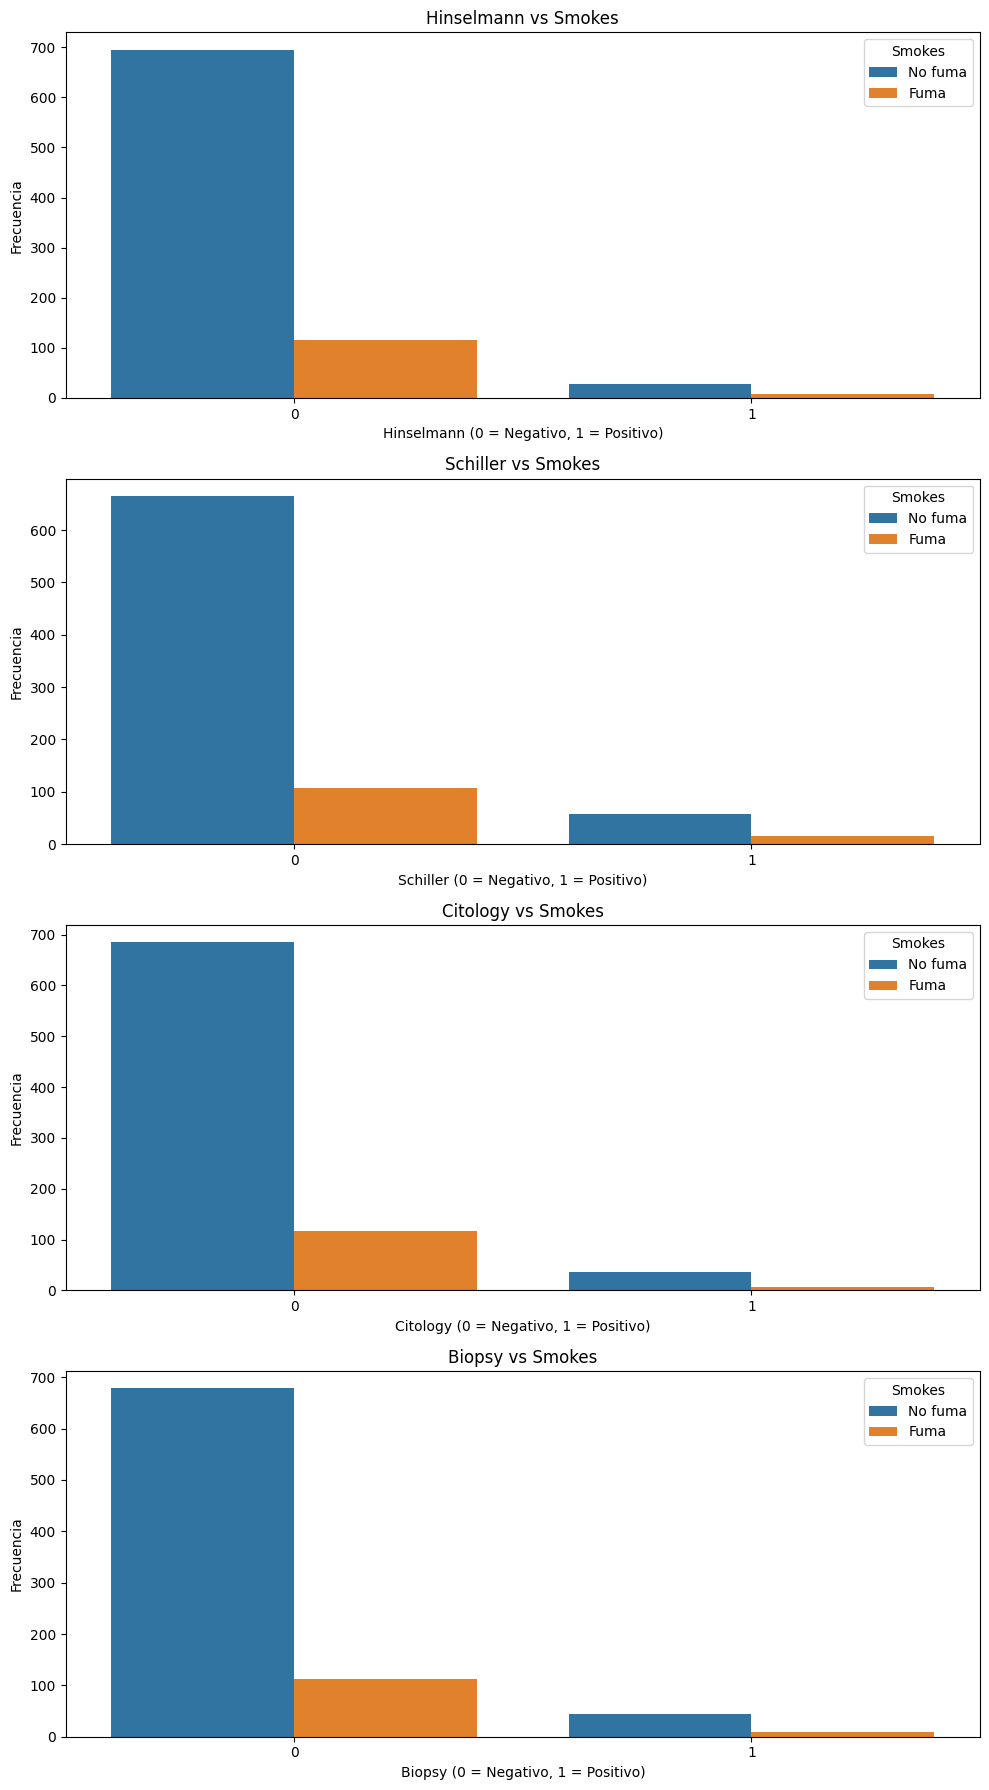

In [187]:
# Lista de variables objetivo y características a comparar
target_vars = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
feature = 'Smokes'

# Crear DataFrame para la comparación
df_comp = df[target_vars + [feature]].copy()

# Convertir a numérico
for col in target_vars + [feature]:
    df_comp[col] = pd.to_numeric(df_comp[col],errors='coerce')
#subplots
fig, axes = plt.subplots(nrows=len(target_vars),ncols=1,figsize=(10, 18))

# Crear gráficas
for i, target in enumerate(target_vars):

    data = df_comp.dropna(subset=[target, feature])

    sns.countplot(
        data=data,
        x=target,
        hue=feature,
        ax=axes[i])

    axes[i].set_title(
        f'{target} vs Smokes')

    axes[i].set_xlabel(
        f'{target} (0 = Negativo, 1 = Positivo)')

    axes[i].set_ylabel(
        'Frecuencia')

    axes[i].legend(
        title='Smokes',
        labels=['No fuma', 'Fuma'])

plt.tight_layout()
plt.show()

Figura 5. visualización bivariable de los 4 valores objetivo en relación a si la paciente fuma o no según su resultado y un intento de visualización de la disperción de datos según los años de fumar en ambas categorías: en los cuales se presenta la variable objetivo en 0 (negativa) con sus 2 barras que representan si la paciente fuma, no fuma, y lo mismo para la categoría 1, es decir si salió positivo en ese estudio si fuma o no fuma y sus estudios dieron positivo. Podemos observar que los datos negativos están sobrerepresentados, y no nos ayuda como tal a detectar patrones en los casos positivos.

Distribución del hábito de fumar entre los casos positivos:


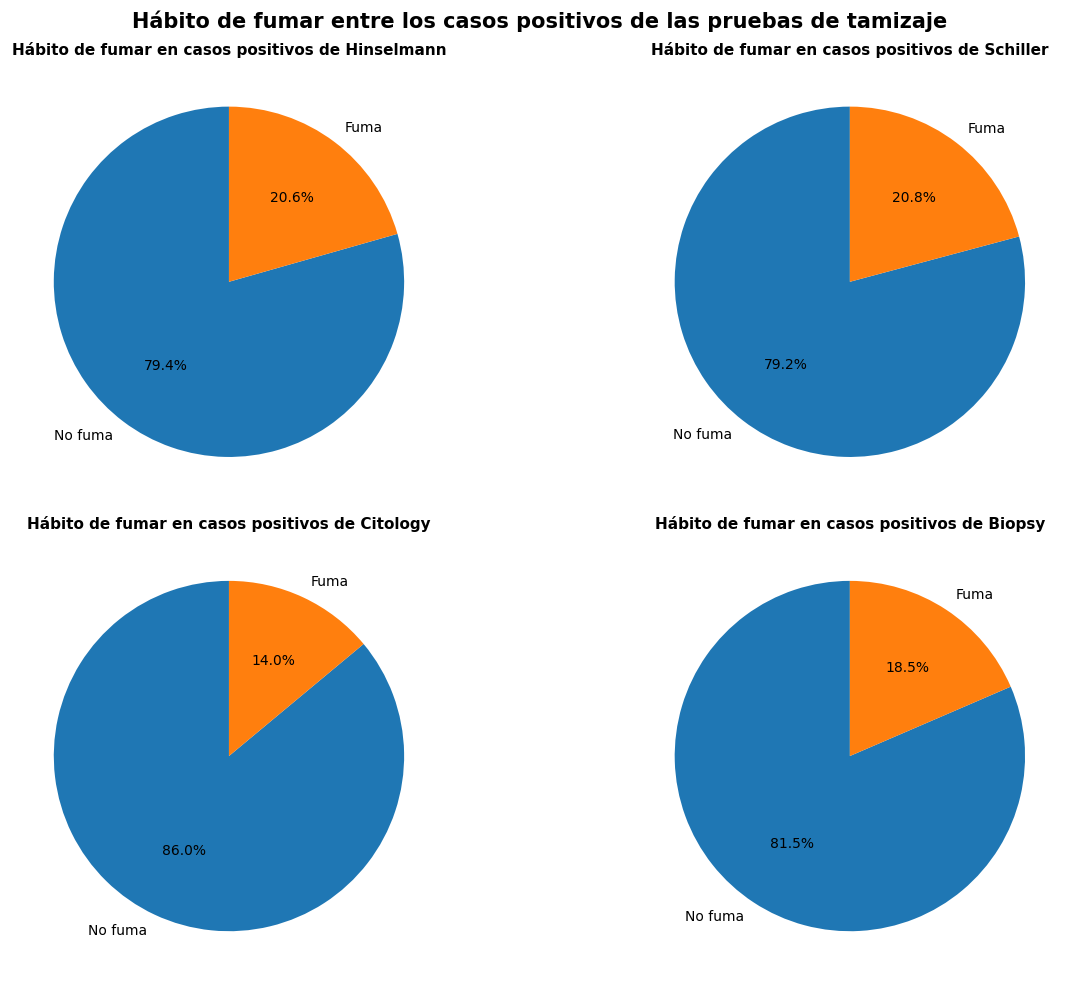

In [191]:
# Variables objetivo
target_vars = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

print("Distribución del hábito de fumar entre los casos positivos:")

plt.figure(figsize=(14, 10))

for i, target in enumerate(target_vars):

    # Crear DataFrame temporal
    df_temp = df[[target, 'Smokes']].copy()

    # Convertir a numérico
    df_temp[target] = pd.to_numeric(df_temp[target], errors='coerce')
    df_temp['Smokes'] = pd.to_numeric(df_temp['Smokes'], errors='coerce')

    # Filtrar únicamente casos positivos
    positives = df_temp[
        (df_temp[target] == 1)
    ].dropna(subset=['Smokes'])

    # Contar fumadoras y no fumadoras
    counts = positives['Smokes'].value_counts().sort_index()

    # Asegurar que existan ambas categorías
    counts = counts.reindex([0, 1], fill_value=0)

    # Gráfica de pastel
    plt.subplot(2, 2, i + 1)

    plt.pie(
        counts.values,
        labels=['No fuma', 'Fuma'],
        autopct='%1.1f%%',
        startangle=90
    )

    plt.title(
        f'Hábito de fumar en casos positivos de {target}',
        fontsize=11,
        fontweight='bold'
    )

plt.suptitle(
    'Hábito de fumar entre los casos positivos de las pruebas de tamizaje',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Figura 6.

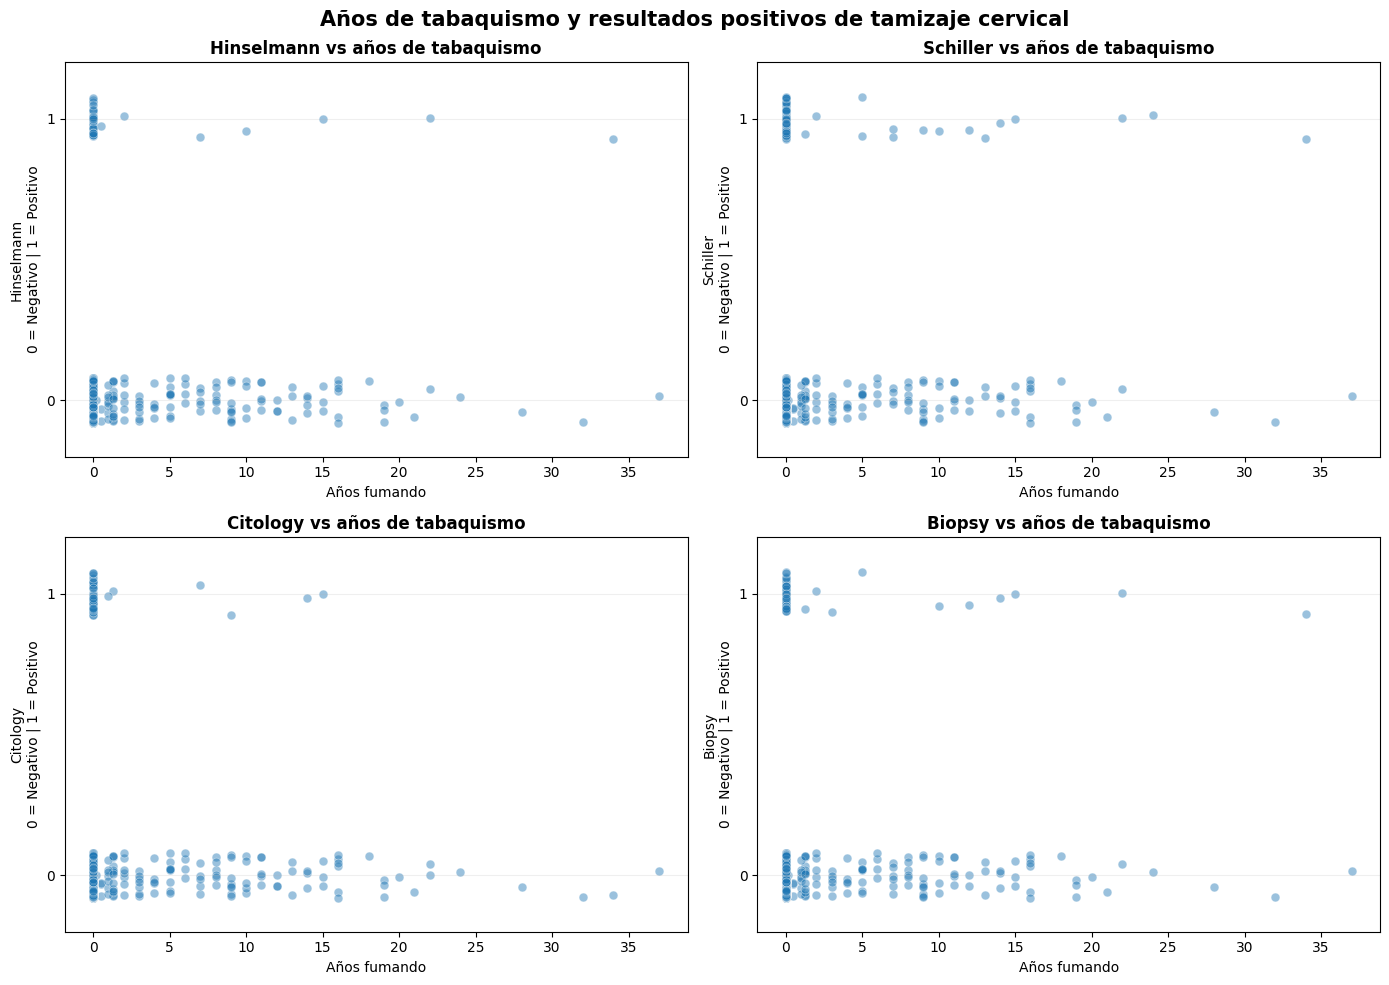

In [190]:
target_vars = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
smoking_var = 'Smokes (years)'

df_scatter = df[target_vars + [smoking_var]].copy()

# Convertir a numérico
for col in target_vars + [smoking_var]:
    df_scatter[col] = pd.to_numeric(df_scatter[col], errors='coerce')

# Crear figura
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10)
)

axes = axes.flatten()

for i, target in enumerate(target_vars):

    data = df_scatter.dropna(subset=[target, smoking_var]).copy()

    # Jitter vertical para separar visualmente los puntos
    np.random.seed(42)
    data['target_jitter'] = (
        data[target] +
        np.random.uniform(-0.08, 0.08, size=len(data))
    )

    sns.scatterplot(
        data=data,
        x=smoking_var,
        y='target_jitter',
        alpha=0.45,
        s=40,
        ax=axes[i]
    )

    axes[i].set_title(
        f'{target} vs años de tabaquismo',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('Años fumando')
    axes[i].set_ylabel(
        f'{target}\n0 = Negativo | 1 = Positivo'
    )

    axes[i].set_yticks([0, 1])
    axes[i].set_ylim(-0.2, 1.2)

    axes[i].grid(
        axis='y',
        alpha=0.2
    )

plt.suptitle(
    'Años de tabaquismo y resultados positivos de tamizaje cervical',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Análisis Multivariado


# Conclusiones

# Referencias  
[1] Organización Mundial de la Salud, «Cáncer de cuello uterino», Notas descriptivas de la OMS, 3 de julio de 2026. [En línea]. Disponible en: https://www.who.int/es/news-room/fact-sheets/detail/cervical-cancer. [Accedido: 17-sep-2026].

[2] K. Fernandes, J. Cardoso, and J. Fernandes. "Cervical Cancer (Risk Factors)," UCI Machine Learning Repository, 2017. [Online]. Available: https://doi.org/10.24432/C5Z310.

[3] M. Likhite, "Cervical Cancer Diagnosis with Machine Learning: Part 1 — Data," Data Science Collective, Medium, Oct. 19, 2025. [Online]. Available: https://medium.com/data-science-collective/cervical-cancer-diagnosis-with-machine-learning-part-1-data-f1e17af779f5. [Accessed: Sep. 17, 2026].

[4] "La madre más prolífica de la historia," Guinness World Records. [Online]. Available: https://www.guinnessworldrecords.com/world-records/most-prolific-mother-ever. [Accessed: Sep. 18, 2026].

[5] "La persona más longeva de la historia," Guinness World Records. [Online]. Available: https://www.guinnessworldrecords.com/world-records/oldest-person. [Accessed: Sep. 18, 2026].

Declaración sobre el uso de inteligencia artificial: Se utilizó ChatGPT y Gemini como herramientas de apoyo para la generación y revisión del código empleado en la elaboración de algunas visualizaciones. La selección de las variables, procesamiento de los datos, análisis estadístico, interpretación de los resultados y conclusiones fueron realizados y verificados por los autores.